# Линейная фильтрация

Рассмотрим примеры линейной фильтрации

# Генерация фильтров

Сначала обсудим методы создания фильтров на примере НЧ фильтра. Для создания фильтра используем алгоритм Парка-МакКлеллана. Для его реализации используем функцию `signal.remez()`.

Среди требуемых параметров надо указать:

    число ненулевых коэффициентов фильтра
    список частот от 0 до fs/2, отмечающих полосу пропускания, полосу перехода, полосу подавления
    указание желаемой амплитуды в полосах частот
    частота дискретизации
    
Список частот формируется с помощью частоты, в которой завершается полоса пропускания `fPass`, и частоты, в которой начинается полоса подавления `fStop`. Разница между этими частотами задают ширину полосы перехода.

In [2]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

Число коэффициентов фильтра:  (25,)


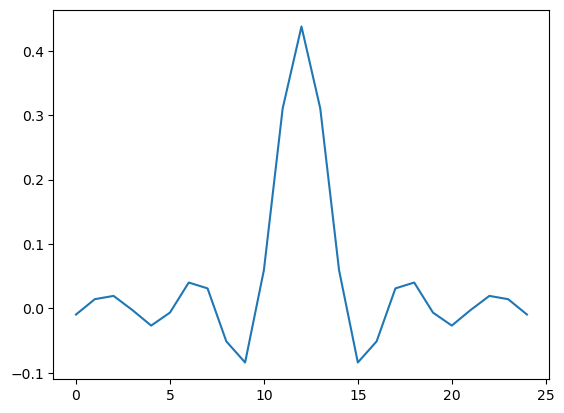

In [3]:
fs = 8000       # частота дискретизации
fPass = 1500   
fStop = 2000  
numtaps = 25      # число коэффициентов фильтра

lp_filter = signal.remez(numtaps, [0, fPass, fStop, 0.5*fs],
                    [1, 0], fs=fs)
print("Число коэффициентов фильтра: ", lp_filter.shape)
# График фильтра во временной области
plt.plot(lp_filter)

Для того, чтобы убедиться, что построенный фильтр удовлетворяет заданным характеристикам, надо найти его АЧХ. Для этого можно проделать ДПФ для вектора коэффициентов фильтра. Однако, в библиотеке Scipy для этого есть специальная функция `signal.freqz()`. Аргументами этой функции являются коэффициенты фильтра. Второй аргумент пока имеет вид `[1]`. Далее его смысл будет раскрыт.

Возвращает эта функция результат ДПФ коэффициентов фильтра (по умолчанию они дополняются нулями до 512), а также сооветствующий вектор с индексами частот. По умолчанию возвращается половина спектра (поскольку вторая половина симметрична). Если параметром указать `fs`, то вернутся "реальные" частоты.

Выведем график АЧХ.

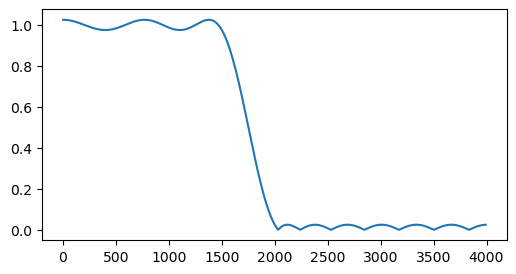

In [4]:
w, h = signal.freqz(lp_filter, [1], fs=fs)
plt.figure(figsize=(6,3))
plt.plot(w, np.abs(h))

Фильтр строится так, что в средней частоте полосы пропускания, то есть 1750Гц, значение АЧХ равно 0.5. Среднюю частоту полосы пропускания ещё называют частотой среза.

Обычно график АЧХ рисуют в логарифмической шкале, то есть в децибелах. В этой шкале лучше видны незаметные в обычном масштабе колебания. Амплитуда 1 будет соответствовать 0 в дБ. Значения амплитуды меньше 1 перейдут в значения меньше нуля.

Поскольку далее, часто будет требоваться построение такого графика, напишем специальную функцию, которая по результату функции `signal.freqz()` рисует АЧХ в лог-шкале.

Значение в дБ АЧХ в частоте среза равно -3 дБ.

In [7]:
10*np.log10(np.abs(0.5))

-3.010299956639812

In [7]:
def plot_response(w, h, fs, title):
    plt.figure(figsize=(5,2))
    plt.plot(w, 10*np.log10(np.abs(h)))
    plt.ylim(-40, 5)
    plt.xlim(0, 0.5*fs)
    plt.grid(True)
    plt.xlabel('Частота')
    plt.ylabel('Амплитуда (дБ)')
    plt.title(title)

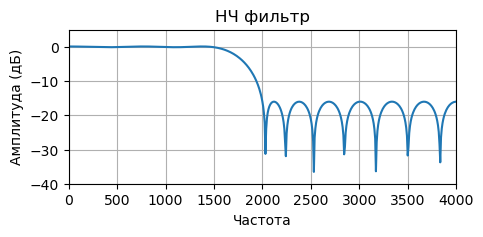

In [7]:
plot_response(w, h, fs,  "НЧ фильтр")

Можно также формировать параметры фильтра исходя из желаемой частоты срезы и ширины полосы пропускания.

Число коэффициентов фильтра:  (25,)


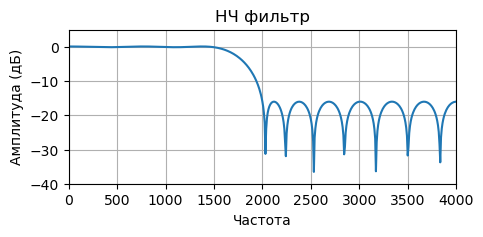

In [8]:
fs = 8000       # частота дискретизации
fCut = 1750    # частота среза в Гц
transition = 500  # ширина полосы перехода в Гц
numtaps = 25      # число коэффициентов фильтра

lp_filter = signal.remez(numtaps, [0, fCut-transition/2, fCut+ transition/2, 0.5*fs],
                    [1, 0], fs=fs)
print("Число коэффициентов фильтра: ", lp_filter.shape)
# График фильтра во временной области
w, h = signal.freqz(lp_filter, [1], fs=fs)
plot_response(w, h, fs,  "НЧ фильтр")

Далее, рассмотрим пример построения ВЧ фильтра. 

In [9]:
fs = 8000       # частота дискретизации
fStop = 1500    # частота среза в Гц
fPass = 2000  # ширина полосы перехода
numtaps = 25      # число коэффициентов фильтра

hp_filter = signal.remez(numtaps, [0, fStop, fPass , 0.5*fs],
                    [0, 1], fs=fs)
print("Число коэффициентов фильтра: ", hp_filter.shape)

Число коэффициентов фильтра:  (25,)


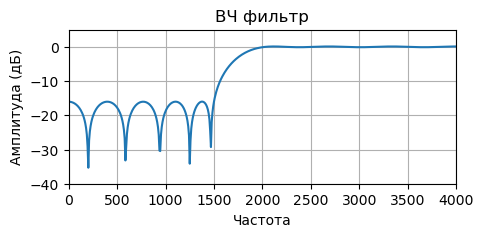

In [10]:
w, h = signal.freqz(hp_filter, [1], fs=fs)
plot_response(w, h, fs,  "ВЧ фильтр")

Далее, рассмотрим полосно-пропускающий фильтр.

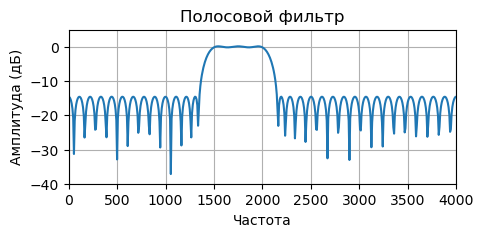

In [11]:
fs = 8000.0       # частота дискретизации
band = [1500, 2000]  # Желаемая полоса пропускания
trans_width = 150  # ширина полосы перехода
numtaps = 75      # число коэффициентов фильтра

edges = [0, band[0] - trans_width,
         band[0], band[1],
         band[1] + trans_width, 0.5*fs]

bp_filter = signal.remez(numtaps, edges, [0, 1, 0], fs=fs)
w, h = signal.freqz(bp_filter, [1], fs=fs)

plot_response( w, h, fs, "Полосовой фильтр")

И полосно-заграждающий фильтр.

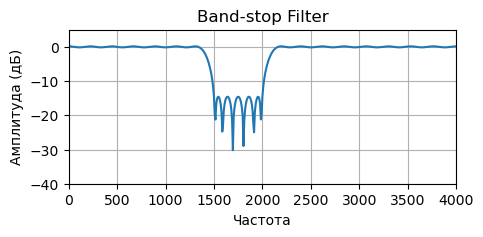

In [12]:
fs = 8000.0       # частота дискретизации
band = [1500, 2000]  # Желаемая полоса пропускания
trans_width = 150  # ширина полосы перехода
numtaps = 75      # число коэффициентов фильтра

edges = [0, band[0] - trans_width,
         band[0], band[1],
         band[1] + trans_width, 0.5*fs]
bs_filter = signal.remez(numtaps, edges, [1, 0, 1], fs=fs)
w, h = signal.freqz(bs_filter, [1], fs=fs)

plot_response( w, h, fs, "Band-stop Filter")

Также в библиотеке `scipy` есть ряд иных методов для генерации фильтров

    firls()  МНК метод
    firwin() оконный метод
    firwin2()

## Линейная фильтрация

Линейная фильтрация производится командой `signal.lfilter()`. На вход подаются коэффициенты фильтра (1-ый и 2-ой аргументы) и сигнал (3-им аргументов). Для КИХ-фильтра с коэффициентами в списке `lp_filter` команда имеет вид

    signal.lfilter(lp_filter, [1], signal)
    
Роль 2-го аргумента будет более ясна после обсуждения БИХ-фильтров.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftshift, rfft
from scipy import signal

def plot_response(w, h, fs, title):
    plt.figure(figsize=(5,2))
    plt.plot(w, 10*np.log10(np.abs(h)))
    plt.ylim(-40, 5)
    plt.xlim(0, 0.5*fs)
    plt.grid(True)
    plt.xlabel('Частота')
    plt.ylabel('Амплитуда (дБ)')
    plt.title(title)

In [17]:
fs = 8000 
filter_size = 50
fpass = 500
fstop = 650 

# Создание фильтра
lp_filter = signal.remez(filter_size,
                 [0, fpass, fstop, fs/2], 
                 [1,0],  # НЧ фильтр
                 fs = fs,
                 )

# Применение фильтра
w,h = signal.freqz(lp_filter, [1], fs=fs) 

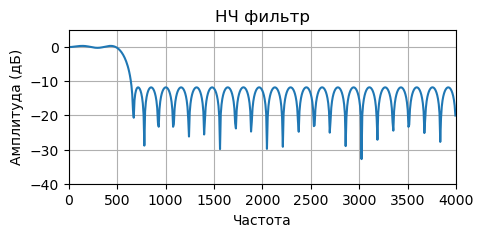

In [18]:
plot_response(w, h, fs, "НЧ фильтр")

Создадим сигнал из 3-х тонов на частотах 440, 660, 880 Гц. А затем создадим фильтр подавляющий частоты выше 500 Гц иприменим его к сигналу.

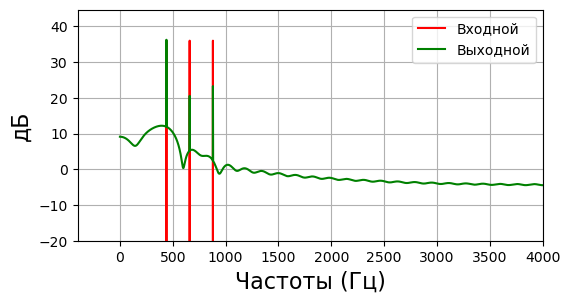

In [19]:
fs =8000
T=1
N = T*fs

t = np.linspace(0,T,N,endpoint=False)
x = np.sin(2*np.pi*440*t) + np.sin(2*np.pi*660*t) + np.sin(2*np.pi*880*t)

xFFT = fft(x,N)

y = signal.lfilter(lp_filter,[1],x)

yFFT = fft(y,N)

fig, ax = plt.subplots(figsize=(6, 3))

ax.plot(np.arange(N)/N*fs,10*np.log10(np.abs(xFFT)),'r-',label='Входной')
ax.plot(np.arange(N)/N*fs,10*np.log10(np.abs(yFFT)),'g-',label='Выходной')
ax.set_xlim(xmax = fs/2)
ax.set_ylim(ymin=-20)
ax.set_ylabel(r'дБ',fontsize=16)
ax.set_xlabel("Частоты (Гц)",fontsize=16)
ax.grid()

ax.legend(loc=0);

In [20]:
import IPython
IPython.display.Audio(x,rate=fs)

In [21]:
import IPython
IPython.display.Audio(y,rate=fs)

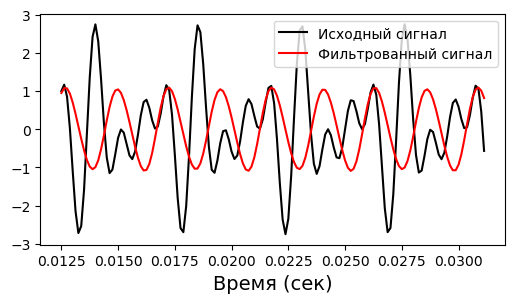

In [22]:
fig,ax = plt.subplots(figsize=(6, 3))

ax.plot(t[100:250],x[100:250],label='Исходный сигнал',color='k')
ax.plot(t[100:250],y[100:250],label='Фильтрованный сигнал',color='r')
ax.set_xlabel("Время (сек)",fontsize=14)
ax.legend(loc=0);

## Смена окраски звука

Рассмотрим эффект ревебрации. Этот эффект создаётся, когда какой-либо звук звучит в замкнутом пространстве, в результате чего отражения от поверхностей стен вызывают большое количество эхо, затем звук медленно затухает по причине поглощения звуковых волн стенами и воздухом.

Пусть мы хотим смоделировать окраску звука, звучащего в некотором пространстве.

Чтобы для некоторого сигнала `x` искусственно создать эффект звучания в этом пространстве, надо отфильтровать его фильтром с импульсной характеристикой `h`, где `h` является записью отклика пространства на $\delta$-импульс (то есть короткий громкий звук, например, выстрел).

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftshift, rfft
from scipy import signal
from scipy.io import wavfile
import IPython

Загрузим сигнал.

In [24]:
fs, data = wavfile.read('source/pianoC4.wav')
#fs, data = wavfile.read('source/interst.wav')
#fs, data = wavfile.read('source/ost_gt4.wav')
#fs, data = wavfile.read('source/example.wav')
#fs, data = wavfile.read('source/guitar.wav')

# Создание одного канала, если 2
if len(data.shape) == 2:
    data = np.mean(data, axis = 1)

# Укорачивание сигнала, если длинный
if len(data)>2*10 **6:
    data = data[:np.int32(len(data)/10)] 
    

IPython.display.Audio(data,rate=fs)

Загрузим импульсную характеристику сигнала.

In [25]:
# загрузка фильтра
fs_filt, filt = wavfile.read('source/impulse_cathedral.wav')
print(data.shape)
IPython.display.Audio(filt,rate=fs_filt)

(29750,)


Создание ревебрации с различными фильтрами

In [26]:
fs_filt, filt = wavfile.read('source/impulse_cathedral.wav')
y = signal.lfilter(np.float16(filt), [1], np.float16(data))
IPython.display.Audio(y, rate=fs)

Ниже представлено ещё несколько различных эффектов.

In [27]:
fs_filt, filt = wavfile.read('source/impulse_revcathedral.wav')
y = signal.lfilter(np.float16(filt), [1], np.float16(data))
IPython.display.Audio(y, rate=fs)

In [37]:
fs_filt, filt = wavfile.read('source/impulse_room.wav')
y = signal.lfilter(np.float16(filt), [1], np.float16(data))
IPython.display.Audio(y, rate=fs)

In [28]:
fs_filt, filt = wavfile.read('source/impulse_bathroom.wav')
y = signal.lfilter(np.float16(filt), [1], np.float16(data))
IPython.display.Audio(y, rate=fs)

Легко также создать эффект эхо у сигнала. Для этого надо реализовать фильтр, действующий по правилу

$y[n] = x[n] - c_1 x[n-d_1] - ... - c_N x[n-d_N]$,

где коэффициенты $c_i$ означают коэффициенты у задержанного сигнала, а индексы $d_i$ означают задержку сигнала на соответствующее число отсчётов.

In [29]:
# формирование фильтра: длина равна 0.15 на fs.
filt = np.zeros(np.int16(0.15*fs))

# и три ненулевых значения: для 1-го и последнего отсчётов, и отсчёта в середине.
filt[0] = 1
filt[np.int16(len(filt)/2)] = 1.2
filt[-1] = 0.6

In [32]:
fs, data = wavfile.read('source/pianoC4.wav')
#fs, data = wavfile.read('source/interst.wav')
#fs, data = wavfile.read('source/ost_gt4.wav')
#fs, data = wavfile.read('source/example.wav')
fs, data = wavfile.read('source/guitar.wav')

# Создание одного канала, если 2
if len(data.shape) == 2:
    data = np.mean(data, axis = 1)

# Укорачивание сигнала, если длинный
if len(data)>2*10 **6:
    data = data[:np.int32(len(data)/10)] 

In [33]:
y = signal.lfilter(np.float16(filt), [1], np.float16(data))
IPython.display.Audio(y, rate=fs)

## Подавление узкочастотного шума

Подгрузим необходимые библотеки и функцию для отрисовки графиков.

In [1]:
from scipy.io import wavfile

import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftshift, rfft, fftfreq
from scipy import signal
import IPython

def myDFT_AmplPlot(t, x, N=512, fs = None, xLim = 0.5):    
    if len(x)>512:
        N = len(x)
        
    xFFT = fftshift(fft(x, N))
    # Амплитуда спектра
    xA = np.abs(xFFT)
    
    if fs == None:
        fs = 1    
    freqs = fftshift(fftfreq(N, d = 1/fs))
    # Графики
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 2, 1)
    plt.title('Сигнал')
    plt.plot(t, x)
    plt.xlabel('Временные отсчёты')

    plt.subplot(1, 2, 2)
    plt.plot(freqs,xA)
    plt.xlabel('Частоты')
    plt.xlim([0, fs*xLim])
    plt.xticks(np.linspace(0, fs*xLim, 11))
    plt.grid()
    plt.tight_layout()

Подгрузим сигнал.

In [15]:
fs, data = wavfile.read('source/LetsGo.wav')
data = data/np.max(data)

C:\Users\keita_a\AppData\Local\Temp\ipykernel_6576\3744463305.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read('source/LetsGo.wav')


In [16]:
IPython.display.Audio(data, rate=fs)

Рассмотрим работу полосно-заграждающих КИХ-фильтров на примере удаления шума одной частоты.

Для того, чтобы качество очищения от шума можно было услышать, добавим шум на частоте, например, 500 Гц.

In [19]:
w = 500
t = np.arange(0,len(data)) / fs
noise = np.sin(2*np.pi*w*t)
y_noised = data + 0.75*noise

IPython.display.Audio(y_noised, rate=fs)

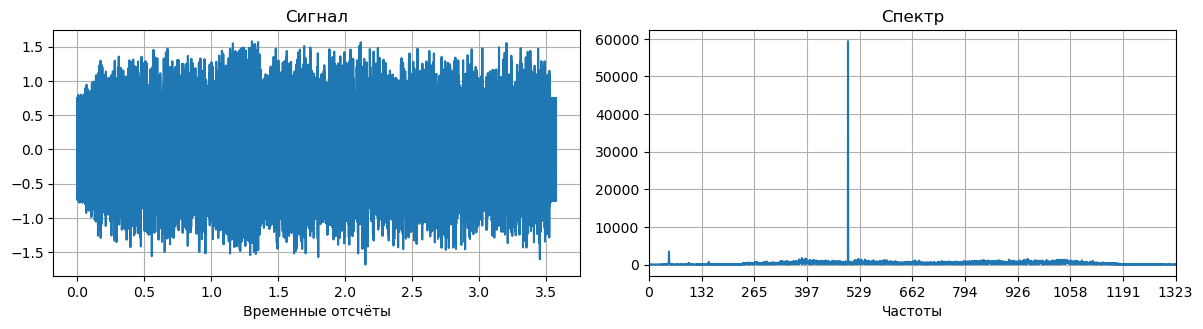

In [38]:
myDFT_AmplPlot(t, y_noised, fs = fs, xLim=0.03)

# ЗАДАЧА 5

Разработать полосно-заграждающий КИХ-фильтр для удаления шума одной частоты из аудио-сигнала.

Создать фильтр можно одним из способов

    signal.remez()
    signal.firls()
    signal.firwin() 

(0.0, 19845.0)

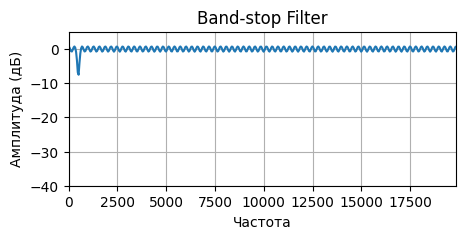

In [17]:
from scipy.signal import remez
from scipy.signal import filtfilt

numtaps = 301         
f_stop = 500          
bandwidth = 30        

f1 = f_stop - bandwidth / 2
f2 = f_stop + bandwidth / 2

# Create band-stop filter using remez
bs_filter = remez(numtaps,
                  [0, f1 - 100, f1, f2, f2 + 100, fs / 2],
                  [1, 0, 1],
                  fs=fs)

w, h = signal.freqz(bs_filter, [1], fs=fs)
plot_response( w, h, fs, "Band-stop Filter")
plt.xlim(0, 0.45*fs)

Провести фильтрацию сигнала.

In [20]:
y_filt = filtfilt(bs_filter, [1.0], y_noised)
IPython.display.Audio(y_filt, rate=fs)

Сравнение спектров исходного сигнала и отфильтрованного.

(0.0, 2205.0)

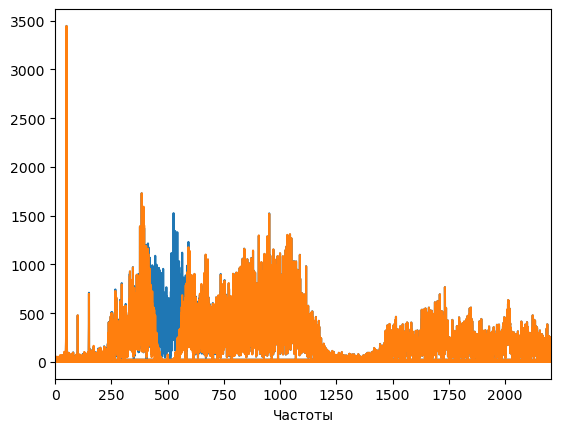

In [39]:
yFFT = np.abs(fft(y_filt))
dataFFT = np.abs(fft(data))
N = len(yFFT)
sig = np.array([dataFFT, yFFT]).T
t= np.arange(N)*fs/N

plt.plot(t,sig)
plt.xlabel('Частоты')
plt.xlim([0, fs*0.05])

Как видно из графиков, шумовая частота была удалена, но вместе со значительной частью полезного сигнала.
Уменьшения потерь полезного сигнала можно добиться путём увеличения отсчётов фильтра.

Как далее будует видно, гораздо более эффективным фильтром для удаления такого шума будет специальный БИХ-фильтр.